In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import torch
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import warnings
warnings.filterwarnings('ignore')

# Check if MPS (Apple Silicon GPU) is available
device = torch.device('mps' if torch.backends.mps.is_available() else 'cpu')
print(f"Using device: {device}")
print("All imports successful!")

Using device: mps
All imports successful!


In [2]:
# Paths
TRAIN_DIR = '../data/raw/chest_xray/chest_xray/train'
VAL_DIR   = '../data/raw/chest_xray/chest_xray/val'
TEST_DIR  = '../data/raw/chest_xray/chest_xray/test'

# Standard size for ResNet/EfficientNet
IMG_SIZE   = 224
BATCH_SIZE = 32

print(f"Image size : {IMG_SIZE}x{IMG_SIZE}")
print(f"Batch size : {BATCH_SIZE}")
print(f"Train path exists: {os.path.exists(TRAIN_DIR)}")
print(f"Test path exists : {os.path.exists(TEST_DIR)}")

Image size : 224x224
Batch size : 32
Train path exists: True
Test path exists : True


In [3]:
# Training transforms - with augmentation to handle imbalance
train_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

# Validation/Test transforms - no augmentation, just resize and normalize
test_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

print("Train transforms:")
print(train_transforms)
print("\nTest transforms:")
print(test_transforms)

Train transforms:
Compose(
    Resize(size=(224, 224), interpolation=bilinear, max_size=None, antialias=True)
    RandomHorizontalFlip(p=0.5)
    RandomRotation(degrees=[-15.0, 15.0], interpolation=nearest, expand=False, fill=0)
    ColorJitter(brightness=(0.8, 1.2), contrast=(0.8, 1.2), saturation=None, hue=None)
    ToTensor()
    Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
)

Test transforms:
Compose(
    Resize(size=(224, 224), interpolation=bilinear, max_size=None, antialias=True)
    ToTensor()
    Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
)


In [4]:
# Load datasets
train_dataset = datasets.ImageFolder(TRAIN_DIR, transform=train_transforms)
val_dataset   = datasets.ImageFolder(TEST_DIR,  transform=test_transforms)
test_dataset  = datasets.ImageFolder(TEST_DIR,  transform=test_transforms)

# Create DataLoaders
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

# Class mapping
print("Class mapping:", train_dataset.class_to_idx)
print(f"\nTraining batches  : {len(train_loader)}")
print(f"Validation batches: {len(val_loader)}")
print(f"Test batches      : {len(test_loader)}")
print(f"\nTotal train images: {len(train_dataset)}")
print(f"Total test images : {len(test_dataset)}")

Class mapping: {'NORMAL': 0, 'PNEUMONIA': 1}

Training batches  : 163
Validation batches: 20
Test batches      : 20

Total train images: 5216
Total test images : 624


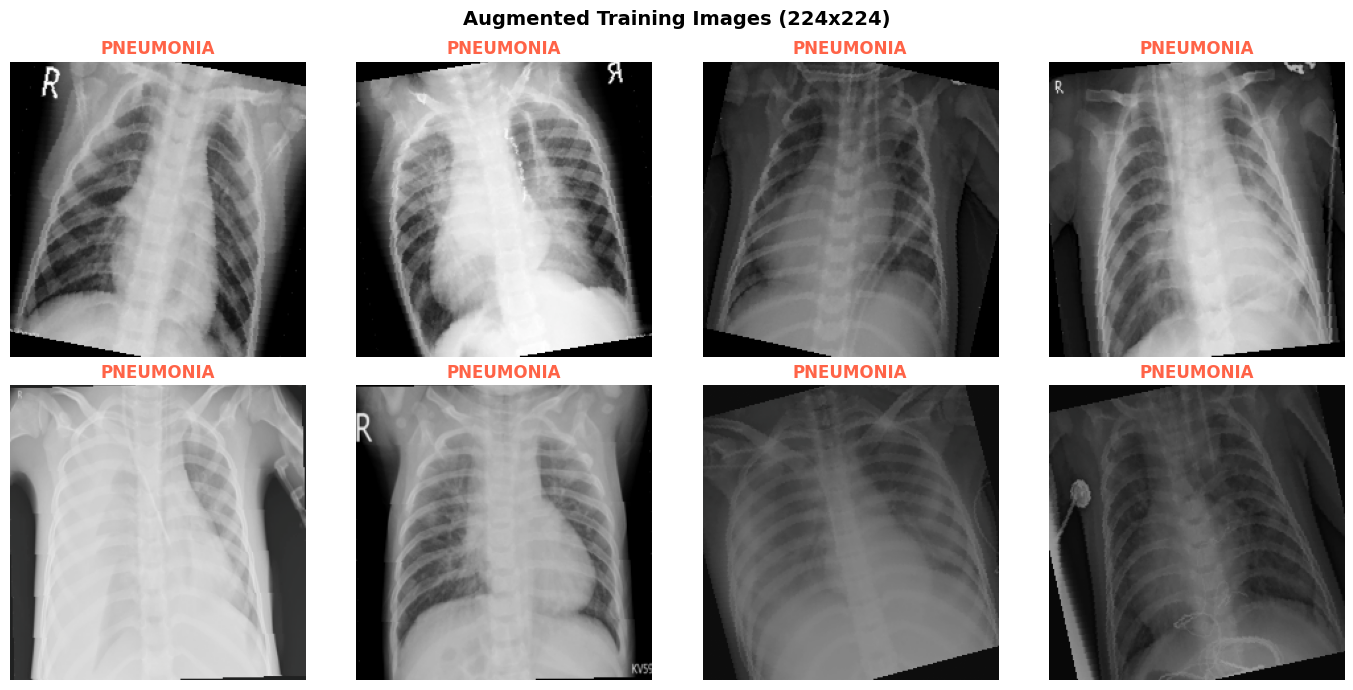

Augmentation pipeline working correctly!


In [5]:
def denormalize(tensor):
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3,1,1)
    std  = torch.tensor([0.229, 0.224, 0.225]).view(3,1,1)
    return torch.clamp(tensor * std + mean, 0, 1)

# Grab one batch
images, labels = next(iter(train_loader))

# Show 8 images from the batch
fig, axes = plt.subplots(2, 4, figsize=(14, 7))
class_names = ['NORMAL', 'PNEUMONIA']
colors      = ['steelblue', 'tomato']

for i, ax in enumerate(axes.flatten()):
    img = denormalize(images[i]).permute(1, 2, 0).numpy()
    label = labels[i].item()
    ax.imshow(img)
    ax.set_title(class_names[label], color=colors[label], fontweight='bold')
    ax.axis('off')

plt.suptitle('Augmented Training Images (224x224)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()
print("Augmentation pipeline working correctly!")

In [6]:
import json

config = {
    'train_dir'  : TRAIN_DIR,
    'val_dir'    : VAL_DIR,
    'test_dir'   : TEST_DIR,
    'img_size'   : IMG_SIZE,
    'batch_size' : BATCH_SIZE,
    'num_classes': 2,
    'class_names': ['NORMAL', 'PNEUMONIA'],
    'class_to_idx': train_dataset.class_to_idx,
    'train_size' : len(train_dataset),
    'test_size'  : len(test_dataset),
    'device'     : str(device)
}

with open('../models/config.json', 'w') as f:
    json.dump(config, f, indent=4)

print("Config saved to models/config.json")
print(json.dumps(config, indent=4))

Config saved to models/config.json
{
    "train_dir": "../data/raw/chest_xray/chest_xray/train",
    "val_dir": "../data/raw/chest_xray/chest_xray/val",
    "test_dir": "../data/raw/chest_xray/chest_xray/test",
    "img_size": 224,
    "batch_size": 32,
    "num_classes": 2,
    "class_names": [
        "NORMAL",
        "PNEUMONIA"
    ],
    "class_to_idx": {
        "NORMAL": 0,
        "PNEUMONIA": 1
    },
    "train_size": 5216,
    "test_size": 624,
    "device": "mps"
}
